### LightGBM

lightGBM or xgboost in theory can extract the non-linear and interaction features directly while pyGam can explore non-linear feature directly. In this notebook, I am trying to testing capability of these package on exploring such features with simulated data

#### Scenario 1: nonlinear features

In [15]:
import numpy as np
import lightgbm as lgb
import shap
from sklearn.model_selection import train_test_split

In [11]:
X = np.random.rand(10_000, 3)
y = X[:, 0] + X[:, 1] ** 2 - X[:, 2] * 3

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

In [18]:
params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "num_leaves": 10,
    "learning_rate": 0.1,
    "feature_fraction": 0.8,
}

In [23]:
model = lgb.train(params, train_data, num_boost_round=100, valid_sets=[train_data, valid_data])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000827 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 3
[LightGBM] [Info] Start training from score -0.646210


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

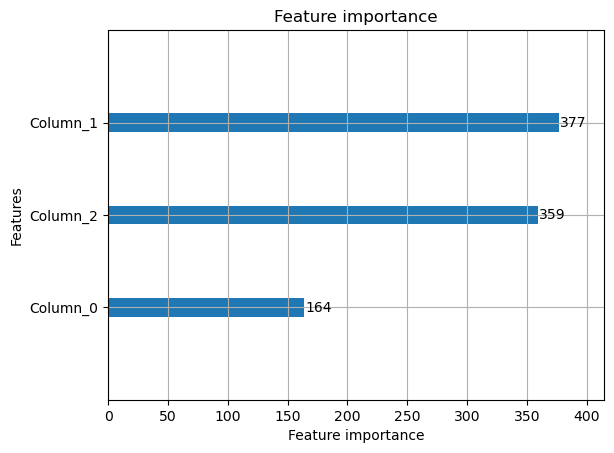

In [24]:
lgb.plot_importance(model, importance_type="split")

looks the more split, the more complex dependency on the feature is?

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

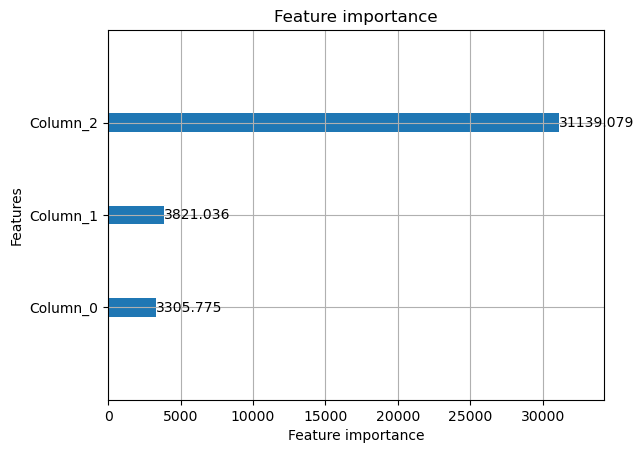

In [25]:
lgb.plot_importance(model, importance_type="gain")

gain looks more like on the contribution based on the value, so that why it is important to normalize the data, otherwise the result can be easily overdominant by the one has larger value?

In [26]:
explainer = shap.TreeExplainer(model)
explanation = explainer(X)

In [27]:
shap_values = explanation.values

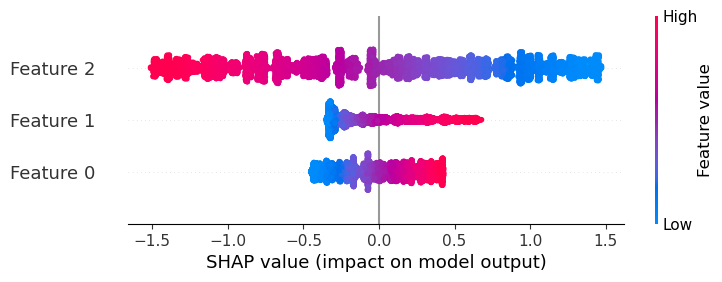

In [31]:
shap.plots.beeswarm(explanation)